In [1]:
# === Cell 1: Advanced harmonisation (Kaggle-only) + de-dup + CSV ===================
# If needed (rare), install cv2:  !pip -q install opencv-python-headless

import csv
from pathlib import Path
import numpy as np
from PIL import Image, ImageOps
import cv2

# --- INPUTS (your original Kaggle folders) ---
ORIG_KAGGLE_H = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project_PreProess_harmonize/Project/Processed/Processed/healthy_kaggle")
ORIG_KAGGLE_C = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Project_PreProess_harmonize/Project/Processed/Processed/cancer")

# --- OUTPUTS (new, versioned) ---
OUT_ROOT   = Path("./Processed_Advanced_Kaggle")  # will be created
OUT_H      = OUT_ROOT / "kaggle_healthy_advanced"
OUT_C      = OUT_ROOT / "kaggle_cancer_advanced"
OUT_CSV    = OUT_ROOT / "metadata_kaggle_advanced.csv"

# --- HYPERPARAMS (deterministic harmonisation) ---
FINAL_SIZE   = 224
APPLY_CLAHE  = True
BORDER_PX    = 0         # set >0 if you also want uniform border; we standardise scale instead
TARGET_OCC   = 0.92      # content occupies ~92% of side after scale normalisation
DUP_HMD_MAX  = 6         # aHash Hamming distance threshold (≤6 => near-duplicate)

OUT_ROOT.mkdir(parents=True, exist_ok=True); OUT_H.mkdir(parents=True, exist_ok=True); OUT_C.mkdir(parents=True, exist_ok=True)
EXTS = (".png",".jpg",".jpeg",".bmp",".tif",".tiff")

def list_images(root: Path):
    return [p for p in root.rglob("*") if p.suffix.lower() in EXTS]

def ahash8(img_u8: np.ndarray) -> int:
    """8x8 average hash on uint8 grayscale [0..255]."""
    small = cv2.resize(img_u8, (8,8), interpolation=cv2.INTER_AREA)
    avg = float(small.mean())
    bits = (small > avg).astype(np.uint8).flatten()
    h = 0
    for b in bits:
        h = (h << 1) | int(b)
    return h

def hamdist(a: int, b: int) -> int:
    return (a ^ b).bit_count()

def harmonize_one(in_path: Path) -> np.ndarray:
    """
    Deterministic advanced harmonisation (class/source-agnostic):
      1) grayscale + resize to FINAL_SIZE
      2) content-scale normalisation (occupancy TARGET_OCC)
      3) per-image Z-score -> clip [-3,3] -> rescale [0,255]
      4) optional mild CLAHE
    """
    # 1) grayscale + base resize
    im = Image.open(in_path).convert("L").resize((FINAL_SIZE, FINAL_SIZE), Image.BICUBIC)
    arr = np.asarray(im, dtype=np.float32)

    # (optional) uniform border, then crop back (disabled by default here)
    if BORDER_PX > 0:
        im = ImageOps.expand(Image.fromarray(arr.astype(np.uint8)), border=BORDER_PX, fill=0)
        im = ImageOps.crop(im, BORDER_PX)
        arr = np.asarray(im, dtype=np.float32)

    # 2) content-scale normalisation
    thr = np.percentile(arr, 60.0)                # low threshold for “ink”
    mask = (arr > thr).astype(np.uint8)
    x, y, w, h = cv2.boundingRect(mask)
    if w > 0 and h > 0:
        target = int(FINAL_SIZE * TARGET_OCC)
        crop   = arr[y:y+h, x:x+w]
        crop   = cv2.resize(crop, (target, target), interpolation=cv2.INTER_CUBIC)
        canvas = np.zeros((FINAL_SIZE, FINAL_SIZE), np.float32)
        s      = (FINAL_SIZE - target) // 2
        canvas[s:s+target, s:s+target] = crop
        arr = canvas

    # 3) per-image z-score -> clip -> [0,255]
    m, s = float(arr.mean()), float(arr.std() + 1e-6)
    arr = (arr - m) / s
    arr = np.clip(arr, -3, 3)
    arr = ((arr + 3.0) / 6.0) * 255.0
    arr = arr.astype(np.uint8)

    # 4) mild CLAHE
    if APPLY_CLAHE:
        clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
        arr = clahe.apply(arr)

    return arr

def process_dir(src_dir: Path, out_dir: Path, label: str):
    out_dir.mkdir(parents=True, exist_ok=True)
    recs, hashes = [], []   # (hash, path)
    for p in sorted(list_images(src_dir)):
        try:
            arr = harmonize_one(p)
        except Exception as e:
            print(f"[WARN] skip {p}: {e}")
            continue
        h = ahash8(arr)
        # near-duplicate filter
        if any(hamdist(h, hh) <= DUP_HMD_MAX for hh,_ in hashes):
            continue
        hashes.append((h, p))
        out_path = out_dir / p.name
        Image.fromarray(arr).save(out_path)
        recs.append({"filepath": str(out_path.resolve()), "label": label, "source": "kaggle"})
    return recs

recs_h = process_dir(ORIG_KAGGLE_H, OUT_H, "healthy")
recs_c = process_dir(ORIG_KAGGLE_C, OUT_C, "cancer")

with OUT_CSV.open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["filepath","label","source"])
    w.writeheader()
    for r in (recs_h + recs_c):
        w.writerow(r)

print("[DONE] Advanced harmonisation complete.")
print(f"Saved: healthy={len(recs_h)} | cancer={len(recs_c)} | total={len(recs_h)+len(recs_c)}")
print(f"CSV @ {OUT_CSV.resolve()}")


[DONE] Advanced harmonisation complete.
Saved: healthy=20 | cancer=15 | total=35
CSV @ /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Processed_Advanced_Kaggle/metadata_kaggle_advanced.csv


In [5]:
# ===================================================================
# PART 2: Train/evaluate on harmonised Kaggle-only data
# ===================================================================

# --- Configuration for Training ---
CSV = OUT_CSV # Use the CSV we just created
IMG_SIZE   = 224
BATCH      = 16 # Smaller batch for a smaller dataset
N_WORKERS  = 0
N_SPLITS   = 5
N_REPEATS  = 10
N_VIEWS    = 5 # More views for a smaller dataset
SEED       = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- Augmentation Definition ---
class SpecMask(torch.nn.Module):
    def __init__(self, time_mask_frac=(0.05,0.15), freq_mask_frac=(0.05,0.15), p=0.8):
        super().__init__()
        self.tmf, self.fmf, self.p = time_mask_frac, freq_mask_frac, p
    def forward(self, x):
        x = x.clone()
        if random.random() < self.p:
            _, H, W = x.shape
            tw = int(random.uniform(*self.tmf) * W)
            t0 = random.randint(0, max(0, W - tw))
            x[:, :, t0:t0+tw] = 0.0
        if random.random() < self.p:
            _, H, W = x.shape
            fh = int(random.uniform(*self.fmf) * H)
            f0 = random.randint(0, max(0, H - fh))
            x[:, f0:f0+fh, :] = 0.0
        return x

# --- Dataset Definition ---
class KaggleDataset(Dataset):
    def __init__(self, df, augment=False):
        self.paths  = df["filepath"].tolist()
        self.labels = (df["label"].astype(str)=="cancer").astype(int).to_numpy()
        base_transforms = [
            tv.transforms.ToTensor(),
            tv.transforms.Lambda(lambda t: t.expand(3, *t.shape[1:])),
        ]
        if augment:
            self.tf = tv.transforms.Compose([
                tv.transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
                tv.transforms.RandomAffine(degrees=10, translate=(0.05,0.05), scale=(0.95,1.05), shear=5),
                tv.transforms.ColorJitter(brightness=0.3, contrast=0.3),
                tv.transforms.GaussianBlur(kernel_size=3, sigma=(0.1,1.5)),
                *base_transforms,
                SpecMask(p=0.8),
                tv.transforms.RandomErasing(p=0.5, scale=(0.02,0.1), ratio=(0.3,3.3)),
                tv.transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.25,0.25,0.25]),
            ])
        else:
            self.tf = tv.transforms.Compose([
                tv.transforms.Resize((IMG_SIZE, IMG_SIZE)),
                *base_transforms,
                tv.transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.25,0.25,0.25]),
            ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        x = Image.open(self.paths[i]).convert("L")
        x = self.tf(x)
        y = self.labels[i]
        return x, y

# --- Feature Extractor and Helper Functions ---
resnet = tv.models.resnet18(weights=tv.models.ResNet18_Weights.IMAGENET1K_V1).to(device).eval()
backbone = torch.nn.Sequential(*(list(resnet.children())[:-1]))

@torch.no_grad()
def embed(dataloader):
    feats, ys = [], []
    for x, y in dataloader:
        x = x.to(device)
        f = backbone(x).flatten(1).cpu().numpy()
        feats.append(f); ys.append(y.numpy())
    return np.vstack(feats), np.concatenate(ys)

def best_f1_tau(y_true, y_score):
    ps, rs, ts = precision_recall_curve(y_true, y_score)
    f1s = (2*ps*rs)/(ps+rs+1e-12)
    idx = np.nanargmax(f1s)
    return float(ts[max(0, idx-1)]) if idx>0 else 0.5

# --- Main Training and Evaluation Loop ---
print("\n--- Starting Repeated Cross-Validation (Kaggle-only) ---")
df = pd.read_csv(CSV)
paths = df["filepath"].tolist()
y_all = (df["label"].astype(str)=="cancer").astype(int).to_numpy()

rkf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
oof_scores = np.zeros_like(y_all, dtype=float)
oof_preds  = np.zeros_like(y_all, dtype=int)

for fold, (tr_idx, te_idx) in enumerate(rkf.split(paths, y_all), 1):
    df_tr = df.iloc[tr_idx].reset_index(drop=True)
    df_te = df.iloc[te_idx].reset_index(drop=True)

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED+fold)
    tr2_idx, va_idx = next(sss.split(df_tr["filepath"], (df_tr["label"].astype(str)=="cancer").astype(int)))
    df_tr2 = df_tr.iloc[tr2_idx].reset_index(drop=True)
    df_va  = df_tr.iloc[va_idx].reset_index(drop=True)

    X_tr_list, y_tr_list = [], []
    for _ in range(N_VIEWS):
        dl_tr = DataLoader(KaggleDataset(df_tr2, augment=True), batch_size=BATCH, shuffle=True, num_workers=N_WORKERS)
        f, y = embed(dl_tr)
        X_tr_list.append(f); y_tr_list.append(y)
    X_tr = np.vstack(X_tr_list); y_tr = np.concatenate(y_tr_list)

    dl_va = DataLoader(KaggleDataset(df_va, augment=False), batch_size=BATCH, shuffle=False, num_workers=N_WORKERS)
    dl_te = DataLoader(KaggleDataset(df_te, augment=False), batch_size=BATCH, shuffle=False, num_workers=N_WORKERS)
    X_va, y_va = embed(dl_va)
    X_te, y_te = embed(dl_te)

    clf = Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression(C=0.1, max_iter=500, class_weight='balanced'))])
    clf.fit(X_tr, y_tr)

    s_val = clf.predict_proba(X_va)[:,1]
    tau   = best_f1_tau(y_va, s_val)
    s_te = clf.predict_proba(X_te)[:,1]
    yhat = (s_te >= tau).astype(int)

    oof_scores[te_idx] = s_te
    oof_preds[te_idx]  = yhat

# --- Aggregate and Report Final Metrics ---
roc_oof = roc_auc_score(y_all, oof_scores)
pr_oof  = average_precision_score(y_all, oof_scores)
f1_oof  = f1_score(y_all, oof_preds)
cm_oof  = confusion_matrix(y_all, oof_preds, labels=[0,1])

print("\n===== Repeated Stratified CV (OOF) =====")
print(f"OOF ROC-AUC={roc_oof:.3f} | OOF PR-AUC={pr_oof:.3f} | OOF F1@τ*={f1_oof:.3f}")
print("Confusion matrix (rows=true [healthy,cancer], cols=pred):")
print(cm_oof)


--- Starting Repeated Cross-Validation (Kaggle-only) ---

===== Repeated Stratified CV (OOF) =====
OOF ROC-AUC=0.903 | OOF PR-AUC=0.902 | OOF F1@τ*=0.778
Confusion matrix (rows=true [healthy,cancer], cols=pred):
[[13  7]
 [ 1 14]]


Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/queues.py", line 239, in _feed
    reader_close()
  File "/usr/lib/python3.11/multiprocessing/connection.py", line 182, in close
    self._close()
  File "/usr/lib/python3.11/multiprocessing/connection.py", line 365, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/usr/lib/python3.11/threading.py", line 975, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.11/multiprocessing/queues.py", line 271, in _feed
    queue_sem.release()
ValueError: semaphore or lock released too many times
Exception

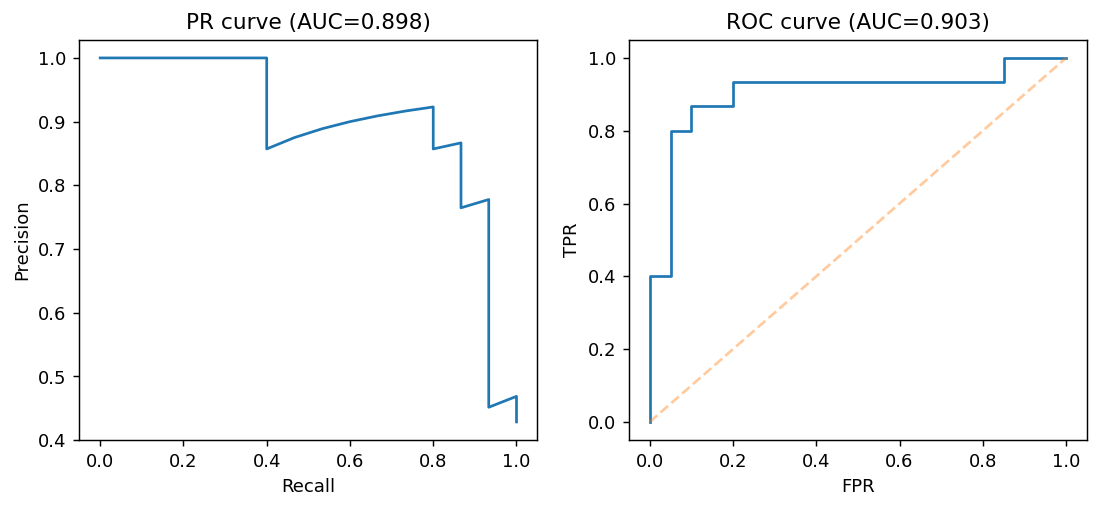

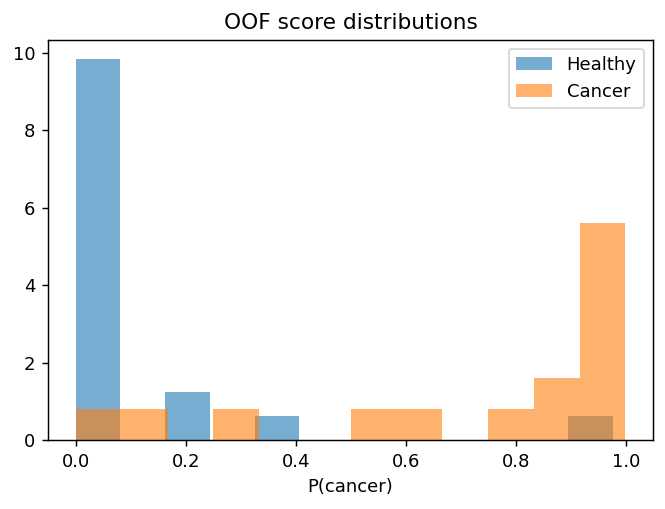

False Positives (7):
  FP: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Processed_Advanced_Kaggle/kaggle_healthy_advanced/Normal 1 (16).png
  FP: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Processed_Advanced_Kaggle/kaggle_healthy_advanced/Normal 1 (20).png
  FP: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Processed_Advanced_Kaggle/kaggle_healthy_advanced/Normal 1 (28).png
  FP: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Processed_Advanced_Kaggle/kaggle_healthy_advanced/Normal 1 (36).png
  FP: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Processed_Advanced_Kaggle/kaggle_healthy_advanced/Normal 1 (45).png
  FP: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/Processed_Advanced_Kaggle/kaggle_healthy_advanced/Normal 1 (46).png
  FP: /workspaces/cmp9137-advanced-machine-learning/CMP

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve, auc, classification_report

# PR & ROC
ps, rs, ts = precision_recall_curve(y_all, oof_scores)
fpr, tpr, _ = roc_curve(y_all, oof_scores)
pr_auc = auc(rs, ps); roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(1,2, figsize=(10,4), dpi=130)
ax[0].plot(rs, ps); ax[0].set_title(f"PR curve (AUC={pr_auc:.3f})"); ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
ax[1].plot(fpr, tpr); ax[1].plot([0,1],[0,1],'--',alpha=0.4)
ax[1].set_title(f"ROC curve (AUC={roc_auc:.3f})"); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
plt.show()

# Score distributions
fig, ax = plt.subplots(1,1, figsize=(6,4), dpi=130)
ax.hist(oof_scores[np.array(y_all)==0], bins=12, alpha=0.6, label="Healthy", density=True)
ax.hist(oof_scores[np.array(y_all)==1], bins=12, alpha=0.6, label="Cancer", density=True)
ax.set_title("OOF score distributions"); ax.set_xlabel("P(cancer)"); ax.legend()
plt.show()

# List FPs/FNs (inspect for residual artefacts)
idx_fp = np.where((np.array(y_all)==0) & (oof_preds==1))[0]
idx_fn = np.where((np.array(y_all)==1) & (oof_preds==0))[0]
print(f"False Positives ({len(idx_fp)}):")
for i in idx_fp[:10]:
    print("  FP:", df.iloc[i]["filepath"])
print(f"\nFalse Negatives ({len(idx_fn)}):")
for i in idx_fn[:10]:
    print("  FN:", df.iloc[i]["filepath"])


In [7]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
rng = np.random.default_rng(0)

def boot_ci(y, s, B=2000):
    aucs, aps = [], []
    n = len(y)
    for _ in range(B):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2:  # guard against degenerate resamples
            continue
        aucs.append(roc_auc_score(y[idx], s[idx]))
        aps.append(average_precision_score(y[idx], s[idx]))
    aucs, aps = np.array(aucs), np.array(aps)
    return (np.median(aucs), np.percentile(aucs,[2.5,97.5])), (np.median(aps), np.percentile(aps,[2.5,97.5]))

(auc_med, auc_ci), (ap_med, ap_ci) = boot_ci(np.array(y_all), np.array(oof_scores))
print(f"ROC-AUC median={auc_med:.3f} 95% CI [{auc_ci[0]:.3f},{auc_ci[1]:.3f}]")
print(f"PR-AUC  median={ap_med:.3f} 95% CI [{ap_ci[0]:.3f},{ap_ci[1]:.3f}]")


ROC-AUC median=0.912 95% CI [0.761,1.000]
PR-AUC  median=0.916 95% CI [0.739,1.000]


In [8]:
from sklearn.metrics import roc_auc_score

obs_auc = roc_auc_score(y_all, oof_scores)
B = 2000
aucs = []
for _ in range(B):
    y_perm = np.random.permutation(y_all)
    aucs.append(roc_auc_score(y_perm, oof_scores))
pval = (np.sum(np.array(aucs) >= obs_auc) + 1) / (B + 1)
print(f"Observed ROC-AUC={obs_auc:.3f} | permutation p-value ≈ {pval:.4f}")


Observed ROC-AUC=0.903 | permutation p-value ≈ 0.0005


In [ ]:
!pip install opencv-python

In [ ]:
pip install --upgrade pip

In [2]:
!apt-get update && apt-get install -y libgl1-mesa-glx

Get:1 http://archive.ubuntu.com/ubuntu jammy InRelease [270 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:5 http://archive.ubuntu.com/ubuntu jammy/restricted amd64 Packages [164 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy/main amd64 Packages [1792 kB]     
Get:7 http://archive.ubuntu.com/ubuntu jammy/universe amd64 Packages [17.5 MB] 
Get:8 http://archive.ubuntu.com/ubuntu jammy/multiverse amd64 Packages [266 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [75.9 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [5430 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3253 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:13 ht